In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving housing_data_no_outliers.csv to housing_data_no_outliers.csv


In [ ]:
df = pd.read_csv("housing_data_no_outliers.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,9100000,6000,4,1,2,yes,no,yes,no,no,2,no,semi-furnished
1,9100000,6600,4,2,2,yes,yes,yes,no,yes,1,yes,unfurnished
2,8960000,8500,3,2,4,yes,no,no,no,yes,2,no,furnished
3,8890000,4600,3,2,2,yes,yes,no,no,yes,2,no,furnished
4,8855000,6420,3,2,2,yes,no,no,no,yes,1,yes,semi-furnished


In [ ]:
df.shape

(530, 13)

In [ ]:
target = "price"

X = df.drop(target, axis = 1)
y = df[target]

In [ ]:
y.head()

,price
0,9100000
1,9100000
2,8960000
3,8890000
4,8855000


In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical features: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder = "passthrough"
)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state =42
)

In [ ]:
print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

Training rows: 424
Testing rows: 106


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_model = Pipeline(steps= [
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [ ]:
linear_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea',
                                                   'furnishingstatus'])])),
                ('model', LinearRegression())])

In [ ]:
linear_predictions = linear_model.predict(X_test)
linear_predictions[:5]

array([5832190.25067734, 4746657.69156273, 6274859.93635191,
       3852171.37479282, 4474905.115559  ])

In [ ]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": linear_predictions
})

comparison.head (10)

,Actual Price,Predicted Price
0,5530000,5.832190e+06
1,3430000,4.746658e+06
2,8680000,6.274860e+06
3,3780000,3.852171e+06
4,3920000,4.474905e+06
5,6300000,5.968058e+06
6,4585000,4.408556e+06
7,2520000,2.462304e+06
8,1890000,2.860865e+06
9,6020000,5.703782e+06


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression Results
MAE: 784877.2641074964
RMSE: 1071542.5911739378
R² Score: 0.6684003582833333


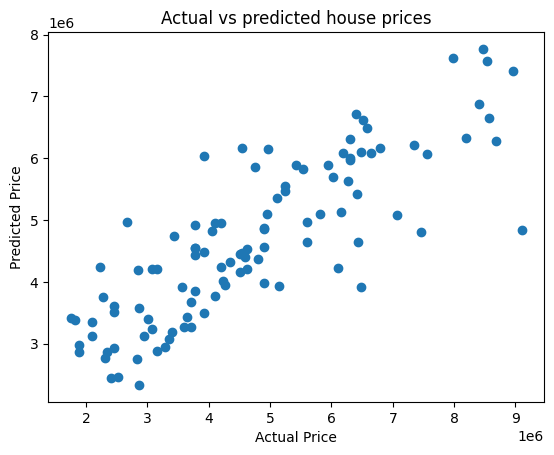

In [ ]:
plt.scatter(y_test, linear_predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs predicted house prices")
plt.show()

In [ ]:
import joblib

In [ ]:
joblib.dump(linear_model, "house_price_model.pkl")

['house_price_model.pkl']

In [ ]:
from google.colab import files
files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Sample data for API and docker

sample_house = pd.DataFrame([{
    "area": 7420,
    "bedrooms": 4,
    "bathrooms": 2,
    "stories": 3,
    "mainroad": "yes",
    "guestroom": "no",
    "basement": "no",
    "hotwaterheating": "no",
    "airconditioning": "yes",
    "parking": 2,
    "prefarea": "yes",
    "furnishingstatus": "furnished"
}])

sample_house.to_csv("sample_house.csv", index=False)
files.download("sample_house.csv")